In [ ]:
# Glider temperature workflow

This notebook downloads and processes Forster glider mission data from the IMOS/ANFOG THREDDS server.

It performs the following steps:
1. Lists delayed-mode and real-time glider missions and their download URLs.
2. Downloads the relevant Forster mission NetCDF files locally.
3. Extracts temperature data, applies QC filtering, and saves masked temperature files.
4. Plots the temperature profiles and regrids the data onto a regular time/depth grid.
5. Compares the glider observations with a seasonal mean profile and produces temperature anomaly plots.

The final outputs include processed NetCDF files and comparison figures for each mission.

In [ ]:
### List all missions

from siphon.catalog import TDSCatalog

### Delayed mode
cat_url = "https://thredds.aodn.org.au/thredds/catalog/IMOS/ANFOG/slocum_glider/catalog.xml"
cat = TDSCatalog(cat_url)

Glider_mission_names_DM = list(cat.catalog_refs.keys())
print(Glider_mission_names_DM)

# optional: write to disk
with open('List_glider_mission_names_DM.txt', 'w') as f:
    f.write('\n'.join(Glider_mission_names_DM))


### Real time
cat_url = "https://thredds.aodn.org.au/thredds/catalog/IMOS/ANFOG/REALTIME/slocum_glider/catalog.xml"
cat = TDSCatalog(cat_url)

Glider_mission_names_RT = list(cat.catalog_refs.keys())
print(Glider_mission_names_RT)

# optional: write to disk
with open('List_glider_mission_names_RT.txt', 'w') as f:
    f.write('\n'.join(Glider_mission_names_RT))

['AIMS20151021', 'AIMS20151127', 'Adelaide20251128', 'BassStrait20160302', 'BassStrait20170321', 'BassStrait20180305', 'BassStrait20180406', 'BassStrait20190123', 'BassStrait20190216', 'BassStrait20200220', 'BassStrait20200706', 'BassStrait20210617', 'BassStrait20210716', 'BassStrait20220422', 'BassStrait20230518', 'BassStrait20231109', 'BassStrait20240321', 'BassStrait20240520', 'BassStrait20250501', 'BassStrait20250819', 'BassStrait20260316', 'BassStrait20260424', 'Bremer20130221', 'Cairns20151130', 'Cairns20160324', 'Cairns20160427', 'Cairns20160726', 'Cairns20180621', 'Cairns20190618', 'Cairns20200514', 'Cairns20230608', 'Cairns20230628', 'CapricornBunker20200307', 'Challenger20180812', 'CharlotteBay20151124', 'Coffs20111112', 'Coffs20250717', 'Cooktown20160217', 'Cooktown20160322', 'Cooktown20160503', 'Cooktown20160727', 'Cooktown20191113', 'Cooktown20221117', 'CrowdyHead20091002', 'Dampier20190523', 'Esperance20250327', 'Esperance20250924', 'Forster120230714', 'Forster20170911', 

In [ ]:
### List all mission urls

from thredds_crawler.crawl import Crawl
import json

catalog_url = "https://thredds.aodn.org.au/thredds/catalog/IMOS/ANFOG/slocum_glider/catalog.xml"

crawler = Crawl(catalog_url)

urls = []

for ds in crawler.datasets:
    for svc in ds.services:
        url = svc.get("url")
        if url and url.endswith(".nc") and "/fileServer/" in url:
            urls.append(url)

# remove duplicates while preserving order
urls = list(dict.fromkeys(urls))

# save as plain text
with open("List_glider_mission_url_DM.txt", "w", encoding="utf-8") as f:
    f.write("\n".join(urls))

# save as JSON too
with open("List_glider_mission_url_DM.json", "w", encoding="utf-8") as f:
    json.dump(urls, f, indent=2)

print(f"Saved {len(urls)} URLs")

Saved 384 URLs


In [ ]:
### Download all historical Forster missions nected files locally

from pathlib import Path
from urllib.parse import urlparse, unquote
import requests

with open("List_glider_mission_url_DM.txt", "r", encoding="utf-8") as f:
    urls = [line.strip() for line in f if line.strip()]

output_dir = Path("Forster_downloads2")
output_dir.mkdir(exist_ok=True)

for url in urls:
    if "Forster" not in url:
        continue

    if not urlparse(url).path.lower().endswith(".nc"):
        continue

    parts = [p for p in urlparse(url).path.split("/") if p]
    campaign = parts[-2]
    filename = parts[-1]
    save_name = f"{campaign}_{unquote(filename)}"

    destination = output_dir / save_name

    if destination.exists():
        print(f"Skipping existing: {save_name}")
        continue

    print(f"Downloading {save_name}")

    with requests.get(url, stream=True, timeout=300) as response:
        response.raise_for_status()

        with destination.open("wb") as file:
            for chunk in response.iter_content(chunk_size=1024 * 1024):
                if chunk:
                    file.write(chunk)

In [68]:
### Split TEMP and TEMP_quality_control from Forster missions and save

import xarray as xr
from pathlib import Path

input_dir = Path("Forster_downloads2")
nc_files = sorted(input_dir.glob("*.nc"))
processed = 0
failed = []

for src in nc_files:
    print(f"Processing {src.name}")
    with xr.open_dataset(src) as ds:
        ds10 = ds.isel(TIME=slice(None, None, 10))
        good = ds10["TEMP_quality_control"].isin([1, 2])
        ds10["TEMP_masked"] = ds10["TEMP"].where(good)
        out = ds10[["TEMP_masked", "TEMP_quality_control", "TIME", "LATITUDE", "LONGITUDE", "DEPTH"]]

        dest = src.with_name(src.stem + "_TEMP.nc")
        out.to_netcdf(dest)

print(f"Saved {processed} TEMP files")
if failed:
    print(f"Skipped {len(failed)} files due to errors:")
    for name in failed:
        print(f" - {name}")

Processing Forster120230714_IMOS_ANFOG_BCEOPSTUV_20230714T051927Z_SL210_FV01_timeseries_END-20230809T001956Z.nc
Processing Forster20170911_IMOS_ANFOG_BCEOPSTUV_20170911T071056Z_SL287_FV01_timeseries_END-20171002T010328Z.nc
Processing Forster20180205_IMOS_ANFOG_BCEOPSTUV_20180204T050812Z_SL248_FV01_timeseries_END-20180226T222617Z.nc
Processing Forster20180505_IMOS_ANFOG_BCEOPSTUV_20180505T071658Z_SL248_FV01_timeseries_END-20180605T215253Z.nc
Processing Forster20180629_IMOS_ANFOG_BCEOPSTUV_20180629T013317Z_SL209_FV01_timeseries_END-20180718T040930Z.nc
Processing Forster20181201_IMOS_ANFOG_BCEOPSTUV_20181201T025752Z_SL286_FV01_timeseries_END-20181219T011552Z.nc
Processing Forster20190312_IMOS_ANFOG_BCEOPSTUV_20190311T234447Z_SL286_FV01_timeseries_END-20190404T044156Z.nc
Processing Forster20190614_IMOS_ANFOG_BCEOPSTUV_20190614T003522Z_SL286_FV01_timeseries_END-20190710T032722Z.nc
Processing Forster20190905_IMOS_ANFOG_BCEOPSTUV_20190905T025053Z_SL286_FV01_timeseries_END-20190929T212941Z.nc


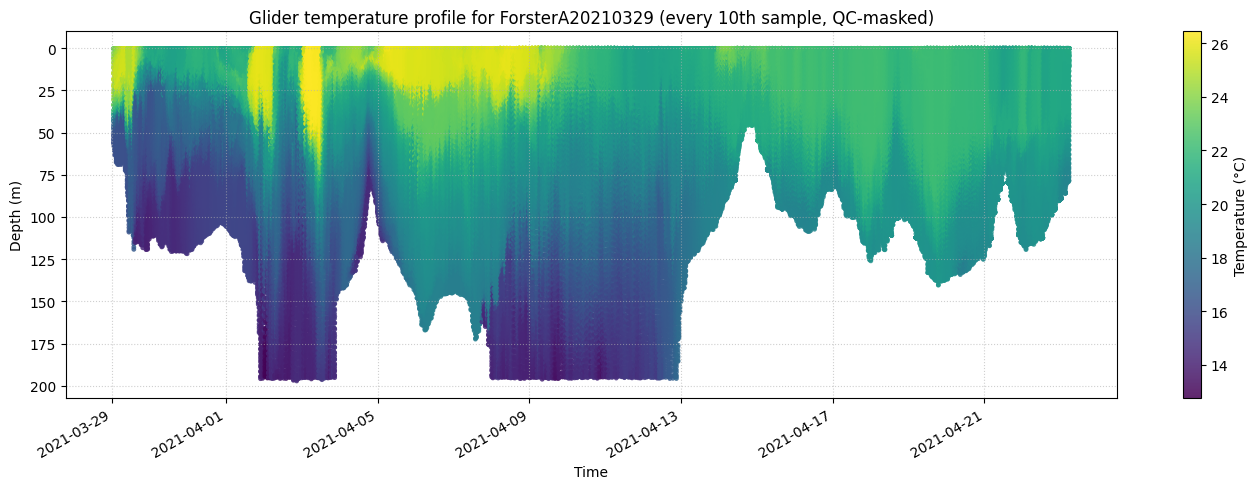

In [ ]:
# Plotting TEMP vs TIME and DEPTH for a specific mission

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(14, 5))
sc = ax.scatter(
    out["TIME"],
    out["DEPTH"],
    c=out["TEMP_masked"],
    cmap="viridis",
    s=12,
    alpha=0.85,
    edgecolors="none",
)
ax.invert_yaxis()
ax.set_xlabel("Time")
ax.set_ylabel("Depth (m)")
mission_name = globals().get("src", Path("unknown")).stem if "src" in globals() else "unknown"
mission_prefix = mission_name.split("_", 1)[0] if isinstance(mission_name, str) else "unknown"
ax.set_title(f"Glider temperature profile for {mission_prefix} (every 10th sample, QC-masked)")
ax.grid(True, linestyle=":", alpha=0.6)
cb = fig.colorbar(sc, ax=ax)
cb.set_label("Temperature (°C)")
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

In [86]:
### Regrid all _TEMP.nc files to a common TIME/DEPTH grid

import numpy as np
import pandas as pd
import xarray as xr
from pathlib import Path

input_dir = Path("Forster_downloads2")
output_dir = Path("Forster_downloads2_regridded")
output_dir.mkdir(exist_ok=True)

temp_files = sorted(input_dir.glob("*_TEMP.nc"))

if not temp_files:
    raise FileNotFoundError("No *_TEMP.nc files found in Forster_downloads2")

depth_grid = np.arange(0, 151, 1)

for src in temp_files:
    print(f"Processing {src.name}")
    ds = xr.open_dataset(src)
    ds = ds.sortby("TIME")

    # Create time_grid for each file individually
    time_grid = pd.date_range(
        start=pd.Timestamp(ds["TIME"].min().values),
        end=pd.Timestamp(ds["TIME"].max().values),
        freq="h",
    )

    times = pd.to_datetime(ds["TIME"].values)
    depths = ds["DEPTH"].values
    temps = ds["TEMP_masked"].values

    temp_grid = np.full((len(time_grid), len(depth_grid)), np.nan)

    for i, t_bin_start in enumerate(time_grid):
        t_bin_end = t_bin_start + pd.Timedelta(hours=1)
        mask = (times >= t_bin_start) & (times < t_bin_end)

        if mask.sum() == 0:
            continue

        d_bin = depths[mask]
        t_bin = temps[mask]

        valid = ~np.isnan(t_bin) & ~np.isnan(d_bin)
        if valid.sum() < 2:
            continue

        d_sorted_idx = np.argsort(d_bin[valid])
        d_sorted = d_bin[valid][d_sorted_idx]
        t_sorted = t_bin[valid][d_sorted_idx]

        try:
            temp_grid[i, :] = np.interp(
                depth_grid, d_sorted, t_sorted, left=np.nan, right=np.nan
            )
        except:
            pass

    out = xr.Dataset(
        data_vars={
            "TEMP_masked": (("DEPTH", "TIME"), temp_grid.T),
            "TEMP_quality_control": (("DEPTH", "TIME"), np.full(temp_grid.T.shape, np.nan)),
        },
        coords={"TIME": time_grid, "DEPTH": depth_grid},
    )
    dest = output_dir / src.name
    out.to_netcdf(dest)
    print(f"Saved {dest}")

print(f"Regridded {len(temp_files)} files to {output_dir}")

Processing Forster120230714_IMOS_ANFOG_BCEOPSTUV_20230714T051927Z_SL210_FV01_timeseries_END-20230809T001956Z_TEMP.nc
Saved Forster_downloads2_regridded\Forster120230714_IMOS_ANFOG_BCEOPSTUV_20230714T051927Z_SL210_FV01_timeseries_END-20230809T001956Z_TEMP.nc
Processing Forster20170911_IMOS_ANFOG_BCEOPSTUV_20170911T071056Z_SL287_FV01_timeseries_END-20171002T010328Z_TEMP.nc
Saved Forster_downloads2_regridded\Forster20170911_IMOS_ANFOG_BCEOPSTUV_20170911T071056Z_SL287_FV01_timeseries_END-20171002T010328Z_TEMP.nc
Processing Forster20180205_IMOS_ANFOG_BCEOPSTUV_20180204T050812Z_SL248_FV01_timeseries_END-20180226T222617Z_TEMP.nc
Saved Forster_downloads2_regridded\Forster20180205_IMOS_ANFOG_BCEOPSTUV_20180204T050812Z_SL248_FV01_timeseries_END-20180226T222617Z_TEMP.nc
Processing Forster20180505_IMOS_ANFOG_BCEOPSTUV_20180505T071658Z_SL248_FV01_timeseries_END-20180605T215253Z_TEMP.nc
Saved Forster_downloads2_regridded\Forster20180505_IMOS_ANFOG_BCEOPSTUV_20180505T071658Z_SL248_FV01_timeseries_END

Dominant month: 7, Selected condition: winter_no_mhw


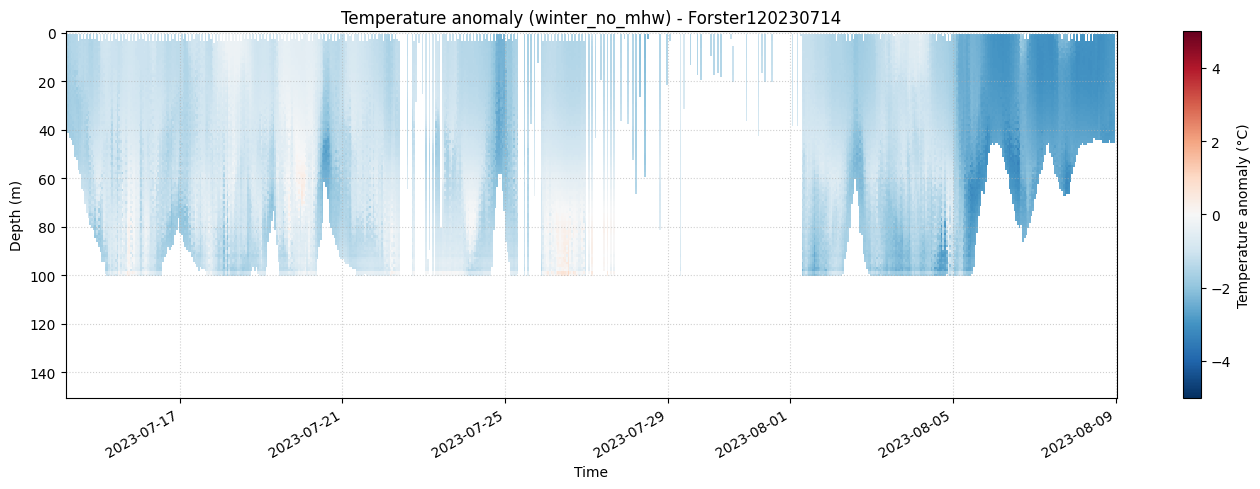

In [ ]:
# ### Calculate temperature anomaly (remove seasonal mean)

# # Load one regridded file
# regrid_dir = Path("Forster_downloads2_regridded")
# regrid_files = sorted(regrid_dir.glob("*_TEMP.nc"))
### remove the seasonal regional mean and plot temp anomaly

# ds_mean = xr.open_dataset("./GLIDERSubsurfacedata/glider_mean_profile_TEMP_NSW.nc")
# ds_mean

# # Use the first file
# ds_regrid = xr.open_dataset(regrid_files[0])

# # Determine the season based on the dominant month in the data
# months = pd.to_datetime(ds_regrid["TIME"].values).month
# month_counts = pd.Series(months).value_counts()
# dominant_month = month_counts.idxmax()

# # Map month to season (Southern Hemisphere)
# if dominant_month in [12, 1, 2]:
#     season = "summer"
# elif dominant_month in [3, 4, 5]:
#     season = "autumn"
# elif dominant_month in [6, 7, 8]:
#     season = "winter"
# elif dominant_month in [9, 10, 11]:
#     season = "spring"

# condition = f"{season}_no_mhw"
# print(f"Dominant month: {dominant_month}, Selected condition: {condition}")

# # Get the mean profile for the detected condition
# mean_profile = ds_mean["mean_profile"].sel(condition=condition)

# # Rename depth to DEPTH to match regridded data
# mean_profile = mean_profile.rename({"depth": "DEPTH"})

# # Interpolate mean_profile to match the DEPTH levels of ds_regrid if needed
# mean_interp = mean_profile.interp(DEPTH=ds_regrid.DEPTH, method="linear")

# # Broadcast subtraction: ds_regrid (DEPTH, TIME) - mean_interp (DEPTH)
# temp_anomaly = ds_regrid["TEMP_masked"] - mean_interp

# # Plot the anomaly
# fig, ax = plt.subplots(figsize=(14, 5))
# pc = ax.pcolormesh(
#     temp_anomaly["TIME"],
#     temp_anomaly["DEPTH"],
#     temp_anomaly,
#     cmap="RdBu_r",
#     shading="auto",
#     vmin=-5,
#     vmax=5,
# )
# ax.invert_yaxis()
# ax.set_xlabel("Time")
# ax.set_ylabel("Depth (m)")
# mission_id = regrid_files[0].stem.split("_IMOS_ANFOG")[0]
# ax.set_title(f"Temperature anomaly ({condition}) - {mission_id}")
# ax.grid(True, linestyle=":", alpha=0.6)
# cb = fig.colorbar(pc, ax=ax)
# cb.set_label("Temperature anomaly (°C)")
# fig.autofmt_xdate()
# plt.tight_layout()
# plt.show()

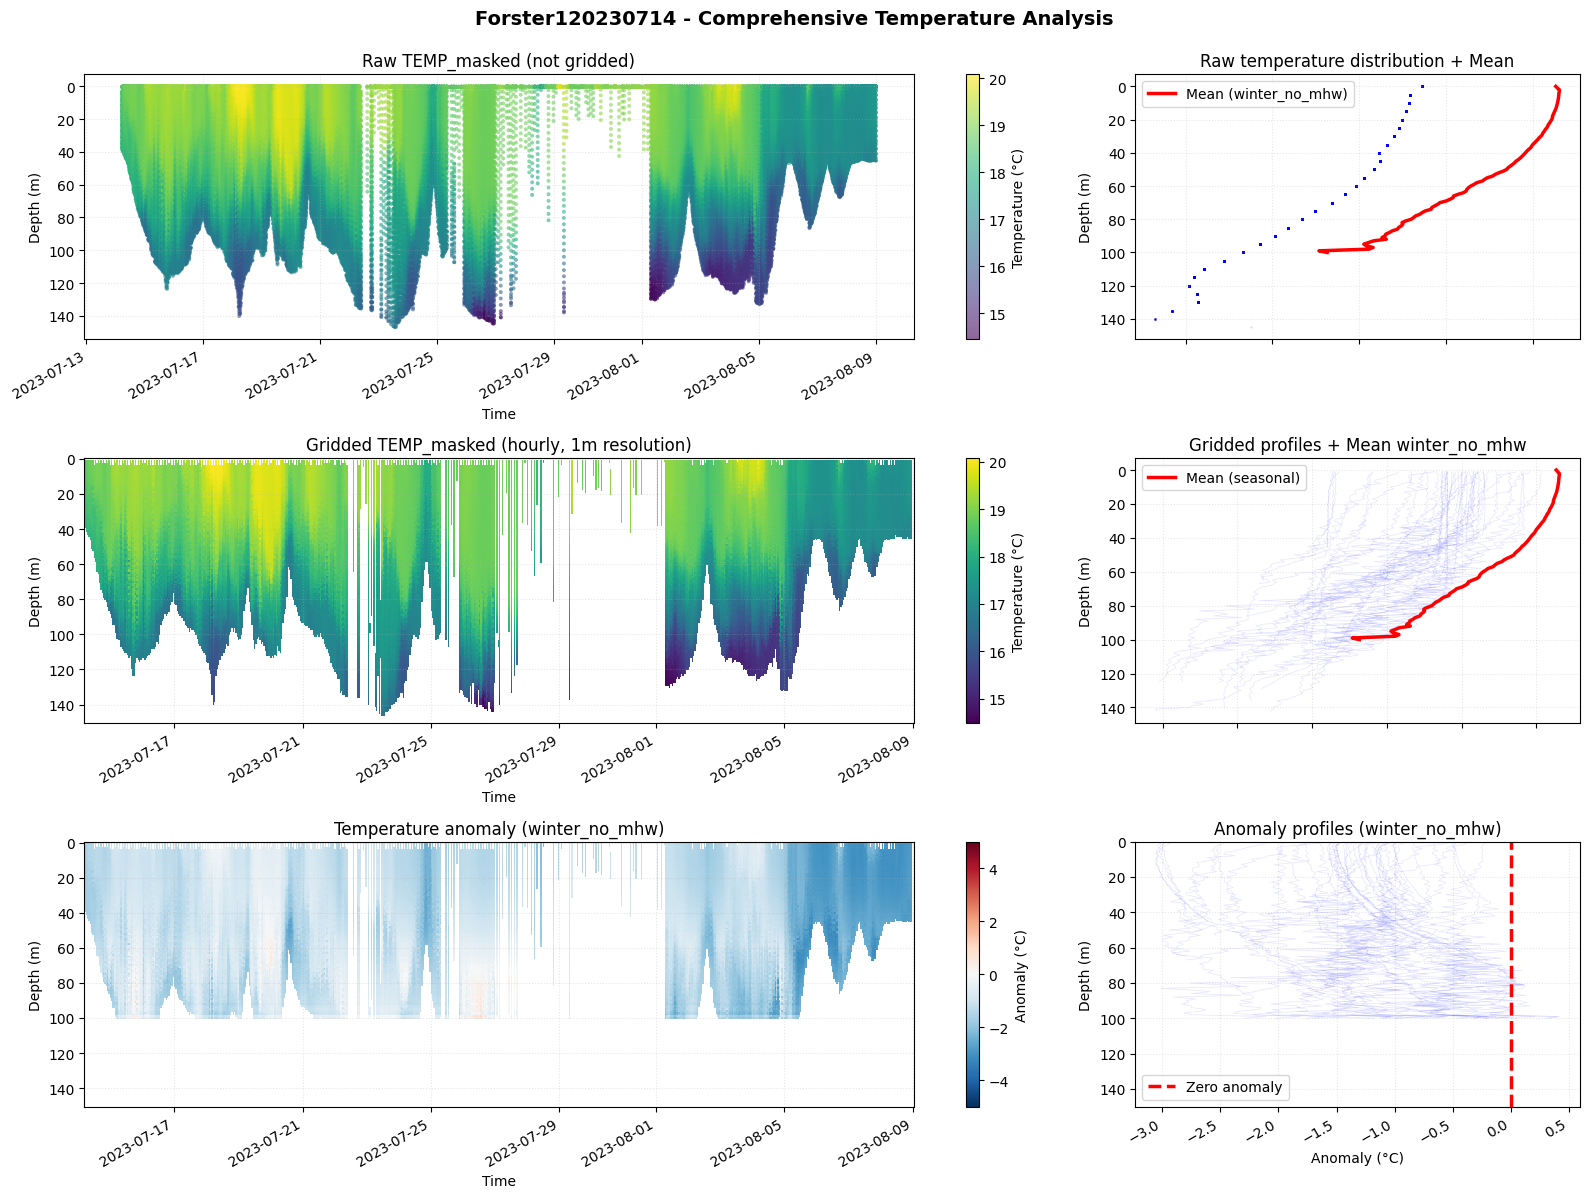

In [ ]:
# ### Comprehensive comparison plot: raw vs gridded vs anomaly (3 rows, 2 columns)

# # Load raw file
# raw_dir = Path("Forster_downloads2")
# raw_files = sorted([f for f in raw_dir.glob("*_TEMP.nc")])
# ds_raw = xr.open_dataset(raw_files[0])

# # Load corresponding gridded file
# regrid_dir = Path("Forster_downloads2_regridded")
# regrid_files = sorted(regrid_dir.glob("*_TEMP.nc"))
# ds_regrid = xr.open_dataset(regrid_files[0])

# # Load mean profile dataset
# ds_mean = xr.open_dataset("./GLIDERSubsurfacedata/glider_mean_profile_TEMP_NSW.nc")

# # Determine season and get mean profile
# months = pd.to_datetime(ds_regrid["TIME"].values).month
# month_counts = pd.Series(months).value_counts()
# dominant_month = month_counts.idxmax()

# if dominant_month in [12, 1, 2]:
#     season = "summer"
# elif dominant_month in [3, 4, 5]:
#     season = "autumn"
# elif dominant_month in [6, 7, 8]:
#     season = "winter"
# elif dominant_month in [9, 10, 11]:
#     season = "spring"

# condition = f"{season}_no_mhw"
# mean_profile = ds_mean["mean_profile"].sel(condition=condition)
# mean_profile = mean_profile.rename({"depth": "DEPTH"})
# mean_interp = mean_profile.interp(DEPTH=ds_regrid.DEPTH, method="linear")
# temp_anomaly = ds_regrid["TEMP_masked"] - mean_interp

# # Calculate anomaly profiles for row 3 right panel
# anomaly_times = temp_anomaly["TIME"].values
# anomaly_depths = temp_anomaly["DEPTH"].values
# anomaly_data = temp_anomaly.values

# mission_id = raw_files[0].stem.split("_IMOS_ANFOG")[0]

# # Create figure with 3 rows, 2 columns
# fig, axes = plt.subplots(3, 2, figsize=(16, 12), gridspec_kw={'width_ratios': [1.4, 0.6]})

# # ROW 1, LEFT: Raw TEMP_masked scatter plot
# ax = axes[0, 0]
# sc1 = ax.scatter(
#     ds_raw["TIME"],
#     ds_raw["DEPTH"],
#     c=ds_raw["TEMP_masked"],
#     cmap="viridis",
#     s=8,
#     alpha=0.6,
#     edgecolors="none",
# )
# ax.invert_yaxis()
# ax.set_xlabel("Time")
# ax.set_ylabel("Depth (m)")
# ax.set_title(f"Raw TEMP_masked (not gridded)")
# ax.grid(True, linestyle=":", alpha=0.3)
# cb1 = fig.colorbar(sc1, ax=ax)
# cb1.set_label("Temperature (°C)")

# # ROW 1, RIGHT: Raw temperature distribution by depth + mean
# ax = axes[0, 1]
# # Create depth bins and average temperature in each bin
# depth_bins = np.arange(0, 151, 5)  # 5m depth bins
# raw_depth = ds_raw["DEPTH"].values
# raw_temp = ds_raw["TEMP_masked"].values
# binned_temps = []
# binned_depths = []
# for i in range(len(depth_bins)-1):
#     mask = (raw_depth >= depth_bins[i]) & (raw_depth < depth_bins[i+1])
#     if mask.sum() > 0:
#         binned_temps.append(raw_temp[mask])
#         binned_depths.append(depth_bins[i])

# # Plot histogram-style distribution
# for d, temps in zip(binned_depths, binned_temps):
#     valid_temps = temps[~np.isnan(temps)]
#     if len(valid_temps) > 0:
#         ax.scatter([valid_temps.mean()]*len(valid_temps), [d]*len(valid_temps), 
#                   alpha=0.01, s=1, color="blue")
# # Plot mean profile
# mean_raw = mean_profile.values
# ax.plot(mean_raw, mean_profile.DEPTH, color="red", linewidth=2.5, label=f"Mean ({condition})")
# ax.invert_yaxis()
# ax.set_xlabel("Temperature (°C)")
# ax.set_ylabel("Depth (m)")
# ax.set_title(f"Raw temperature distribution + Mean")
# ax.legend()
# ax.grid(True, linestyle=":", alpha=0.3)

# # ROW 2, LEFT: Gridded TEMP_masked pcolormesh
# ax = axes[1, 0]
# pc2 = ax.pcolormesh(
#     ds_regrid["TIME"],
#     ds_regrid["DEPTH"],
#     ds_regrid["TEMP_masked"],
#     cmap="viridis",
#     shading="auto",
# )
# ax.invert_yaxis()
# ax.set_xlabel("Time")
# ax.set_ylabel("Depth (m)")
# ax.set_title(f"Gridded TEMP_masked (hourly, 1m resolution)")
# ax.grid(True, linestyle=":", alpha=0.3)
# cb2 = fig.colorbar(pc2, ax=ax)
# cb2.set_label("Temperature (°C)")

# # ROW 2, RIGHT: Gridded temperature profiles + mean
# ax = axes[1, 1]
# # Plot individual profiles
# for i in range(0, len(ds_regrid["TIME"]), max(1, len(ds_regrid["TIME"])//50)):  # Sample ~50 profiles
#     ax.plot(ds_regrid["TEMP_masked"].isel(TIME=i), ds_regrid["DEPTH"], alpha=0.1, color="blue", linewidth=0.5)
# # Plot mean profile
# ax.plot(mean_raw, mean_profile.DEPTH, color="red", linewidth=2.5, label="Mean (seasonal)")
# ax.invert_yaxis()
# ax.set_xlabel("Temperature (°C)")
# ax.set_ylabel("Depth (m)")
# ax.set_title(f"Gridded profiles + Mean {condition}")
# ax.legend()
# ax.grid(True, linestyle=":", alpha=0.3)

# # ROW 3, LEFT: Temperature anomaly pcolormesh
# ax = axes[2, 0]
# pc3 = ax.pcolormesh(
#     temp_anomaly["TIME"],
#     temp_anomaly["DEPTH"],
#     temp_anomaly,
#     cmap="RdBu_r",
#     shading="auto",
#     vmin=-5,
#     vmax=5,
# )
# ax.invert_yaxis()
# ax.set_xlabel("Time")
# ax.set_ylabel("Depth (m)")
# ax.set_title(f"Temperature anomaly ({condition})")
# ax.grid(True, linestyle=":", alpha=0.3)
# cb3 = fig.colorbar(pc3, ax=ax)
# cb3.set_label("Anomaly (°C)")

# # ROW 3, RIGHT: Anomaly profiles
# ax = axes[2, 1]
# # Plot individual anomaly profiles
# for i in range(0, len(anomaly_times), max(1, len(anomaly_times)//50)):  # Sample ~50 profiles
#     valid = ~np.isnan(anomaly_data[:, i])
#     ax.plot(anomaly_data[valid, i], anomaly_depths[valid], alpha=0.1, color="blue", linewidth=0.5)
# # Add zero line
# ax.axvline(0, color="red", linewidth=2.5, linestyle="--", label="Zero anomaly")
# ax.invert_yaxis()
# ax.set_xlabel("Anomaly (°C)")
# ax.set_ylabel("Depth (m)")
# ax.set_title(f"Anomaly profiles ({condition})")
# ax.legend()
# ax.set_ylim(150,0)
# ax.grid(True, linestyle=":", alpha=0.3)

# fig.suptitle(f"{mission_id} - Comprehensive Temperature Analysis", fontsize=14, fontweight="bold", y=0.995)
# fig.autofmt_xdate()
# plt.tight_layout()
# plt.show()

In [106]:
### Loop the same comparison over all Forster mission files

from matplotlib import pyplot as plt

raw_dir = Path("Forster_downloads2")
regrid_dir = Path("Forster_downloads2_regridded")
out_dir = Path("Forster_comparison_plots")
out_dir.mkdir(exist_ok=True)

raw_files = sorted(raw_dir.glob("*_TEMP.nc"))

for raw_file in raw_files:
    regrid_file = regrid_dir / raw_file.name
    if not regrid_file.exists():
        print(f"Skipping {raw_file.name}: no matching regridded file")
        continue

    print(f"Processing {raw_file.name}")

    ds_raw = xr.open_dataset(raw_file)
    ds_regrid = xr.open_dataset(regrid_file)

    months = pd.to_datetime(ds_regrid["TIME"].values).month
    month_counts = pd.Series(months).value_counts()
    dominant_month = month_counts.idxmax()

    if dominant_month in [12, 1, 2]:
        season = "summer"
    elif dominant_month in [3, 4, 5]:
        season = "autumn"
    elif dominant_month in [6, 7, 8]:
        season = "winter"
    else:
        season = "spring"

    condition = f"{season}_no_mhw"
    condition_mhw = f"{season}_mhw"
    mean_profile = ds_mean["mean_profile"].sel(condition=condition)
    mean_profile = mean_profile.rename({"depth": "DEPTH"})
    mean_profile_mhw = ds_mean["mean_profile"].sel(condition=condition_mhw)
    mean_profile_mhw = mean_profile_mhw.rename({"depth": "DEPTH"})
    mean_interp = mean_profile.interp(DEPTH=ds_regrid.DEPTH, method="linear")
    temp_anomaly = ds_regrid["TEMP_masked"] - mean_interp

    anomaly_times = temp_anomaly["TIME"].values
    anomaly_depths = temp_anomaly["DEPTH"].values
    anomaly_data = temp_anomaly.values

    mission_id = raw_file.stem.split("_IMOS_ANFOG")[0]

    fig, axes = plt.subplots(3, 2, figsize=(16, 12), gridspec_kw={"width_ratios": [1.4, 0.6]})

    ax = axes[0, 0]
    sc1 = ax.scatter(
        ds_raw["TIME"],
        ds_raw["DEPTH"],
        c=ds_raw["TEMP_masked"],
        cmap="viridis",
        s=8,
        alpha=0.6,
        edgecolors="none",
    )
    ax.invert_yaxis()
    ax.set_xlabel("Time")
    ax.set_ylabel("Depth (m)")
    ax.set_title("Raw TEMP_masked (not gridded)")
    ax.grid(True, linestyle=":", alpha=0.3)
    fig.colorbar(sc1, ax=ax, label="Temperature (°C)")

    ax = axes[0, 1]
    depth_bins = np.arange(0, 151, 5)
    raw_depth = ds_raw["DEPTH"].values
    raw_temp = ds_raw["TEMP_masked"].values
    for i in range(len(depth_bins) - 1):
        mask = (raw_depth >= depth_bins[i]) & (raw_depth < depth_bins[i + 1])
        if mask.sum() > 0:
            valid_temps = raw_temp[mask][~np.isnan(raw_temp[mask])]
            if len(valid_temps) > 0:
                ax.scatter([valid_temps.mean()] * len(valid_temps), [depth_bins[i]] * len(valid_temps), alpha=0.01, s=1, color="blue")
    ax.plot(mean_profile.values, mean_profile.DEPTH, color="orange", linewidth=2.5, label=f"Mean ({condition})")
    ax.plot(mean_profile_mhw.values, mean_profile_mhw.DEPTH, '--', color="red", linewidth=0.5, label=f"Mean ({condition_mhw})")
    ax.invert_yaxis()
    ax.set_xlabel("Temperature (°C)")
    ax.set_ylabel("Depth (m)")
    ax.set_title("Raw temperature distribution + Mean")
    ax.legend()
    ax.grid(True, linestyle=":", alpha=0.3)

    ax = axes[1, 0]
    pc2 = ax.pcolormesh(
        ds_regrid["TIME"],
        ds_regrid["DEPTH"],
        ds_regrid["TEMP_masked"],
        cmap="viridis",
        shading="auto",
    )
    ax.invert_yaxis()
    ax.set_xlabel("Time")
    ax.set_ylabel("Depth (m)")
    ax.set_title("Gridded TEMP_masked")
    ax.grid(True, linestyle=":", alpha=0.3)
    fig.colorbar(pc2, ax=ax, label="Temperature (°C)")

    ax = axes[1, 1]
    for i in range(0, len(ds_regrid["TIME"]), max(1, len(ds_regrid["TIME"]) // 50)):
        ax.plot(ds_regrid["TEMP_masked"].isel(TIME=i), ds_regrid["DEPTH"], alpha=0.1, color="blue", linewidth=0.5)
    ax.plot(mean_profile.values, mean_profile.DEPTH, color="orange", linewidth=2.5, label=f"Mean ({condition})")
    ax.plot(mean_profile_mhw.values, mean_profile_mhw.DEPTH, '--', color="red", linewidth=0.5, label=f"Mean ({condition_mhw})")
    ax.invert_yaxis()
    ax.set_xlabel("Temperature (°C)")
    ax.set_ylabel("Depth (m)")
    ax.set_title(f"Gridded profiles + Mean {condition}")
    ax.legend()
    ax.grid(True, linestyle=":", alpha=0.3)

    ax = axes[2, 0]
    pc3 = ax.pcolormesh(
        temp_anomaly["TIME"],
        temp_anomaly["DEPTH"],
        temp_anomaly,
        cmap="RdBu_r",
        shading="auto",
        vmin=-5,
        vmax=5,
    )
    ax.invert_yaxis()
    ax.set_xlabel("Time")
    ax.set_ylabel("Depth (m)")
    ax.set_title(f"Temperature anomaly ({condition})")
    ax.grid(True, linestyle=":", alpha=0.3)
    fig.colorbar(pc3, ax=ax, label="Anomaly (°C)")

    ax = axes[2, 1]
    for i in range(0, len(anomaly_times), max(1, len(anomaly_times) // 50)):
        valid = ~np.isnan(anomaly_data[:, i])
        ax.plot(anomaly_data[valid, i], anomaly_depths[valid], alpha=0.1, color="blue", linewidth=0.5)
    ax.axvline(0, color="orange", linewidth=2.5, linestyle="--", label="Zero anomaly")
    ax.invert_yaxis()
    ax.set_xlabel("Anomaly (°C)")
    ax.set_ylabel("Depth (m)")
    ax.set_title(f"Anomaly profiles ({condition})")
    ax.legend()
    ax.set_ylim(150, 0)
    ax.grid(True, linestyle=":", alpha=0.3)

    fig.suptitle(f"{mission_id} - Comprehensive Temperature Analysis", fontsize=14, fontweight="bold", y=0.995)
    fig.autofmt_xdate()
    plt.tight_layout()

    out_path = out_dir / f"{mission_id}_comparison.png"
    fig.savefig(out_path, dpi=200, bbox_inches="tight")
    plt.close(fig)
    print(f"Saved {out_path}")

print("Finished looping over all Forster files")

Processing Forster120230714_IMOS_ANFOG_BCEOPSTUV_20230714T051927Z_SL210_FV01_timeseries_END-20230809T001956Z_TEMP.nc
Saved Forster_comparison_plots\Forster120230714_comparison.png
Processing Forster20170911_IMOS_ANFOG_BCEOPSTUV_20170911T071056Z_SL287_FV01_timeseries_END-20171002T010328Z_TEMP.nc
Saved Forster_comparison_plots\Forster20170911_comparison.png
Processing Forster20180205_IMOS_ANFOG_BCEOPSTUV_20180204T050812Z_SL248_FV01_timeseries_END-20180226T222617Z_TEMP.nc
Saved Forster_comparison_plots\Forster20180205_comparison.png
Processing Forster20180505_IMOS_ANFOG_BCEOPSTUV_20180505T071658Z_SL248_FV01_timeseries_END-20180605T215253Z_TEMP.nc
Saved Forster_comparison_plots\Forster20180505_comparison.png
Processing Forster20180629_IMOS_ANFOG_BCEOPSTUV_20180629T013317Z_SL209_FV01_timeseries_END-20180718T040930Z_TEMP.nc
Saved Forster_comparison_plots\Forster20180629_comparison.png
Processing Forster20181201_IMOS_ANFOG_BCEOPSTUV_20181201T025752Z_SL286_FV01_timeseries_END-20181219T011552Z_

In [ ]:
# ### List all missions Useless for now, but can be used to get the list of all missions and their URLs

# from thredds_crawler.crawl import Crawl

# import xarray as xr

# catalog_url = "https://thredds.aodn.org.au/thredds/catalog/IMOS/ANFOG/slocum_glider/catalog.html"
# crawler = Crawl(catalog_url)
# crawler.datasets

# # crawler.datasets is a list of LeafDataset objects
# for ds in crawler.datasets:
#     # ds.name is something like the filename
#     # ds.services gives you list of access services (HTTPServer, OPeNDAP etc.)

#     for svc in ds.services:
#         url = svc.get("url")
#         if url.endswith(".nc"):
#             print(url)

#             # optional: write to disk
#             with open('List_glider_mission_url_DM.txt', 'w') as f:
#                 f.write((''.join(url)))

https://thredds.aodn.org.au/thredds/dodsC/IMOS/ANFOG/slocum_glider/AIMS20151021/IMOS_ANFOG_BCEOPSTUVN_20151021T035731Z_SL416_FV01_timeseries_END-20151027T015319Z.nc
https://thredds.aodn.org.au/thredds/fileServer/IMOS/ANFOG/slocum_glider/AIMS20151021/IMOS_ANFOG_BCEOPSTUVN_20151021T035731Z_SL416_FV01_timeseries_END-20151027T015319Z.nc
https://thredds.aodn.org.au/thredds/wms/IMOS/ANFOG/slocum_glider/AIMS20151021/IMOS_ANFOG_BCEOPSTUVN_20151021T035731Z_SL416_FV01_timeseries_END-20151027T015319Z.nc
https://thredds.aodn.org.au/thredds/dodsC/IMOS/ANFOG/slocum_glider/AIMS20151127/IMOS_ANFOG_BCEOPSTUVN_20151126T035130Z_SL416_FV01_timeseries_END-20151215T231233Z.nc
https://thredds.aodn.org.au/thredds/fileServer/IMOS/ANFOG/slocum_glider/AIMS20151127/IMOS_ANFOG_BCEOPSTUVN_20151126T035130Z_SL416_FV01_timeseries_END-20151215T231233Z.nc
https://thredds.aodn.org.au/thredds/wms/IMOS/ANFOG/slocum_glider/AIMS20151127/IMOS_ANFOG_BCEOPSTUVN_20151126T035130Z_SL416_FV01_timeseries_END-20151215T231233Z.nc
http